# 6.6 Sourcing & Analyzing Time-Series Data
## Table of Contents
01. Imports/Pathways
02. Data Inspection
03. Cleaning
04. Wrangling
    - Country Alignment for Time-Series Analysis
    - Subsetting for Time-Series Analysis: Colombia
    - Datetime and Indexing
05. Time-series analysis: decomposition
06. Testing for stationarity
07. Summary of Stationarity and Autocorrelation Analysis  

## 01. Imports/Pathways

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')

In [2]:
# File Pathway
path = r"C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee"

In [3]:
# Import Main dataset
df_coffee_m = pd.read_csv(
    r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\02_Data\Prepared_Data\Coffee_Datasets_Merged.csv')

In [4]:
# Import Time series datasest
df_coffee_time = pd.read_csv(
    r'C:\Users\Chase\anaconda_projects\Exercise_6_Coffee\A6_Coffee\02_Data\Original_Data\time_series_coffee_production_by_region\coffee-production-by-region.csv')

## 02. Data Inspection

#### Times Series Data

In [5]:
df_coffee_time.head()

,Entity,Code,Year,"Coffee, green | 00000656 || Production | 005510 || tonnes"
0,Africa,NaN,1961,870970.0
1,Africa,NaN,1962,883512.0
2,Africa,NaN,1963,996674.0
3,Africa,NaN,1964,1162048.0
4,Africa,NaN,1965,1075084.0


In [6]:
df_coffee_time.columns

Index(['Entity', 'Code', 'Year',
       'Coffee, green | 00000656 || Production | 005510 || tonnes'],
      dtype='object')

In [7]:
df_coffee_time.shape

(7263, 4)

In [8]:
df_coffee_time.dtypes

Entity                                                        object
Code                                                          object
Year                                                           int64
Coffee, green | 00000656 || Production | 005510 || tonnes    float64
dtype: object

#### Main Dataset

In [9]:
df_coffee_m.head()

,coffee_name,total_score,roast_level,agtron_roast,price_usd,quantity_g,usd_per_gram,roaster_location,roaster_city,roaster_region,...,body,balance,uniformity,clean_cup,sweetness,cupper_points,total_cup_points,moisture,unit_of_measurement,altitude_mean_meters
0,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.58,7.58,10.0,10.0,10.0,7.58,83.17,0.11,m,NaN
1,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.75,7.50,10.0,10.0,10.0,7.50,83.00,0.00,m,NaN
2,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.67,7.83,10.0,10.0,10.0,7.58,82.67,0.21,m,NaN
3,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.67,7.42,10.0,10.0,10.0,7.25,82.08,0.11,m,NaN
4,colombia finca campo hermosa,94.0,light,82.0,29.99,226.8,$29.99 / 226.8g,"cleveland, tennessee",cleveland,tennessee,...,7.08,7.42,10.0,10.0,10.0,7.25,80.67,0.18,m,NaN


In [10]:
df_coffee_m.columns

Index(['coffee_name', 'total_score', 'roast_level', 'agtron_roast',
       'price_usd', 'quantity_g', 'usd_per_gram', 'roaster_location',
       'roaster_city', 'roaster_region', 'roaster_country', 'coffee_origin',
       'coffee_city', 'coffee_region', 'coffee_country', 'species', 'owner',
       'local_partner', 'harvest_year', 'variety', 'processing_method',
       'aroma', 'flavor', 'aftertaste', 'acidity', 'body', 'balance',
       'uniformity', 'clean_cup', 'sweetness', 'cupper_points',
       'total_cup_points', 'moisture', 'unit_of_measurement',
       'altitude_mean_meters'],
      dtype='object')

In [11]:
df_coffee_m.shape

(8877, 35)

## 03. Cleaning

In [15]:
# Check for missing observations
df_coffee_time.isnull().sum()

Entity                                                       0
Year                                                         0
Coffee, green | 00000656 || Production | 005510 || tonnes    0
dtype: int64

In [14]:
# Remove unnecessary column: code
df_coffee_time.drop(columns=['Code'], inplace=True)

The Code column contained over 2,000 missing entries and was not relevant to the analysis, so I removed it.

In [18]:
# Check for duplicates
df_coffee_time.duplicated().sum()

np.int64(0)

In [16]:
# Rename column
df_coffee_time.rename(columns={
    'Coffee, green | 00000656 || Production | 005510 || tonnes': 'production_tonnes'
}, inplace=True)

In [17]:
# Work check
df_coffee_time.columns

Index(['Entity', 'Year', 'production_tonnes'], dtype='object')

## 04. Wrangling

### Country Alignment for Time-Series Analysis

Going to look at the two datasets to find if they have countries in common. This will allow me to run a time-series analysis on the main dataset’s current countries and expand the analysis. By identifying shared geographic keys, I can potentially merge or compare production trends with quality scores, roast levels, or other attributes from the main dataset. This step sets the foundation for deeper, portfolio-worthy insights while keeping the workflow modular and teachable.

In [21]:
# List unique country/region names in the time-series dataset
print("Time-Series Dataset Countries:")
print(df_coffee_time['Entity'].unique())

# List unique country names in the main dataset
print("\nMain Dataset Countries:")
print(df_coffee_m['coffee_country'].unique())

Time-Series Dataset Countries:
['Africa' 'Africa (FAO)' 'Americas (FAO)' 'Angola' 'Asia' 'Asia (FAO)'
 'Belize' 'Benin' 'Bolivia' 'Brazil' 'Burundi' 'Cambodia' 'Cameroon'
 'Cape Verde' 'Caribbean (FAO)' 'Central African Republic'
 'Central America (FAO)' 'China' 'China (FAO)' 'Colombia' 'Comoros'
 'Congo' 'Cook Islands' 'Costa Rica' "Cote d'Ivoire" 'Cuba'
 'Democratic Republic of Congo' 'Dominica' 'Dominican Republic'
 'East Timor' 'Eastern Africa (FAO)' 'Eastern Asia (FAO)' 'Ecuador'
 'El Salvador' 'Equatorial Guinea' 'Ethiopia' 'Ethiopia (former)' 'Europe'
 'Europe (FAO)' 'European Union (27)' 'Fiji' 'French Polynesia' 'Gabon'
 'Ghana' 'Guadeloupe' 'Guatemala' 'Guinea' 'Guyana' 'Haiti'
 'High-income countries' 'Honduras' 'India' 'Indonesia' 'Jamaica' 'Kenya'
 'Land Locked Developing Countries (FAO)' 'Laos'
 'Least Developed Countries (FAO)' 'Liberia'
 'Low Income Food Deficit Countries (FAO)' 'Low-income countries'
 'Lower-middle-income countries' 'Madagascar' 'Malawi' 'Malaysia'
 'M

##### Mutual Countries

After inspecting the unique country names in both datasets, I confirmed that every country listed in the main dataset is also present in the time-series dataset. These shared entries allow me to run time-series analysis on production trends and potentially compare them with quality metrics from the main dataset. This alignment ensures geographic consistency and opens the door to deeper, portfolio-ready insights.

Confirmed matches include:
- Colombia
- Ethiopia
- Panama
- Taiwan
- Peru
- Tanzania
- Costa Rica
- Brazil
- United States
- Rwanda
- Guatemala
- Kenya
- Mexico
- Yemen
- Indonesia
- El Salvador
- Honduras
- Burundi
- Nicaragua

### Subsetting for Time-Series Analysis: Colombia

To begin time-series analysis, I created a subset of the time-series dataset that includes only Colombia. This allows me to focus on a single, uninterrupted production trend and run decomposition, stationarity testing, and autocorrelation checks. I used a Boolean filter to select rows where the Entity column = Colombia and created a copy to avoid modifying the original dataset.

In [22]:
# Subset the time-series dataset for Colombia
df_colombia = df_coffee_time[df_coffee_time['Entity'] == 'Colombia'].copy()

In [23]:
# Convert the year column to datetime
df_colombia['datetime'] = pd.to_datetime(df_colombia['Year'], format='%Y')

In [25]:
# Datetime as Index
df_colombia.set_index('datetime', inplace=True)

In [26]:
# Drop Unused Columns
df_colombia.drop(columns=['Entity', 'Year'], inplace=True)

In [27]:
# Work check
df_colombia.head()

,production_tonnes
datetime,
1961-01-01,450000.0
1962-01-01,482100.0
1963-01-01,450000.0
1964-01-01,468000.0
1965-01-01,492000.0


In [31]:
# Check for missing values
df_colombia.isnull().sum()

production_tonnes    0
dtype: int64

In [ ]:
# Check for duplicates

### Datetime and Indexing

To prepare the Colombia subset for time-series analysis, I converted the Year column to datetime format and set it as the index. This enables time-aware functions like decomposition and autocorrelation. I also dropped the Entity and Year columns to keep the dataset clean and focused — since all rows are Colombia and the datetime index replaces the original year column.

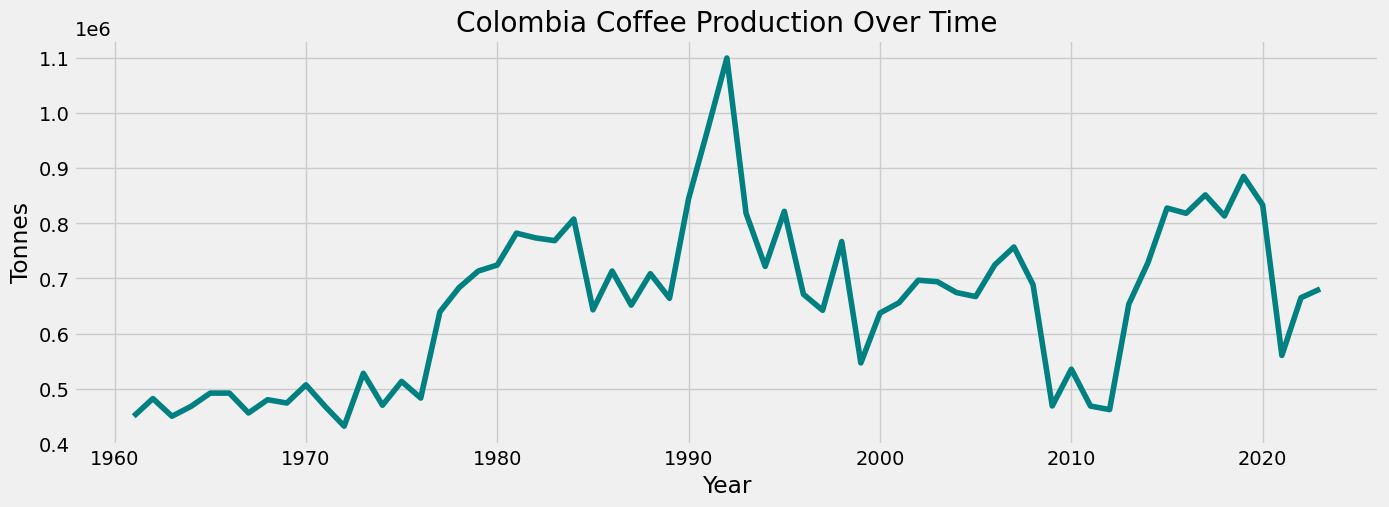

In [30]:
# Line Plot of Colombia Coffee Production (matplotlib)
plt.figure(figsize=(15, 5), dpi=100)
plt.plot(df_colombia['production_tonnes'], color='teal')
plt.title('Colombia Coffee Production Over Time')
plt.xlabel('Year')
plt.ylabel('Tonnes')
plt.grid(True)
plt.show()


##### Wrangle Section Summary

The Colombia subset is now fully prepared for time-series analysis. I confirmed the datetime index and production values through a line plot, which revealed meaningful fluctuations and long-term trends. With the data clean and structured, I’m ready to begin decomposition and stationarity testing in the next section.

## 05. Time-series analysis: decomposition

### Focused Decomposition: 1990–2020

To improve interpretability and focus on modern production dynamics, I filtered the dataset to include only years from 1990 onward. This range captures the most relevant trend shifts and avoids early data that may be sparse or less reliable.

In [39]:
# Filter to recent years (e.g., 1990 onward) to focus on modern production trends
df_recent = df_colombia[df_colombia.index >= '1990']

In [32]:
# Import the seasonal_decompose function from statsmodels.tsa.seasonal
# This function is used to break a time series into trend, seasonal, and residual components.
from statsmodels.tsa.seasonal import seasonal_decompose

In [33]:
# Import rcParams from pylab to set a consistent figure size for decomposition plots.
from pylab import rcParams

In [34]:
# Set default figure size to 18 inches wide by 7 inches tall.
rcParams['figure.figsize'] = 18, 7

In [40]:
# Decompose the filtered series using an additive model
decomposition = seasonal_decompose(df_recent['production_tonnes'], model='additive')

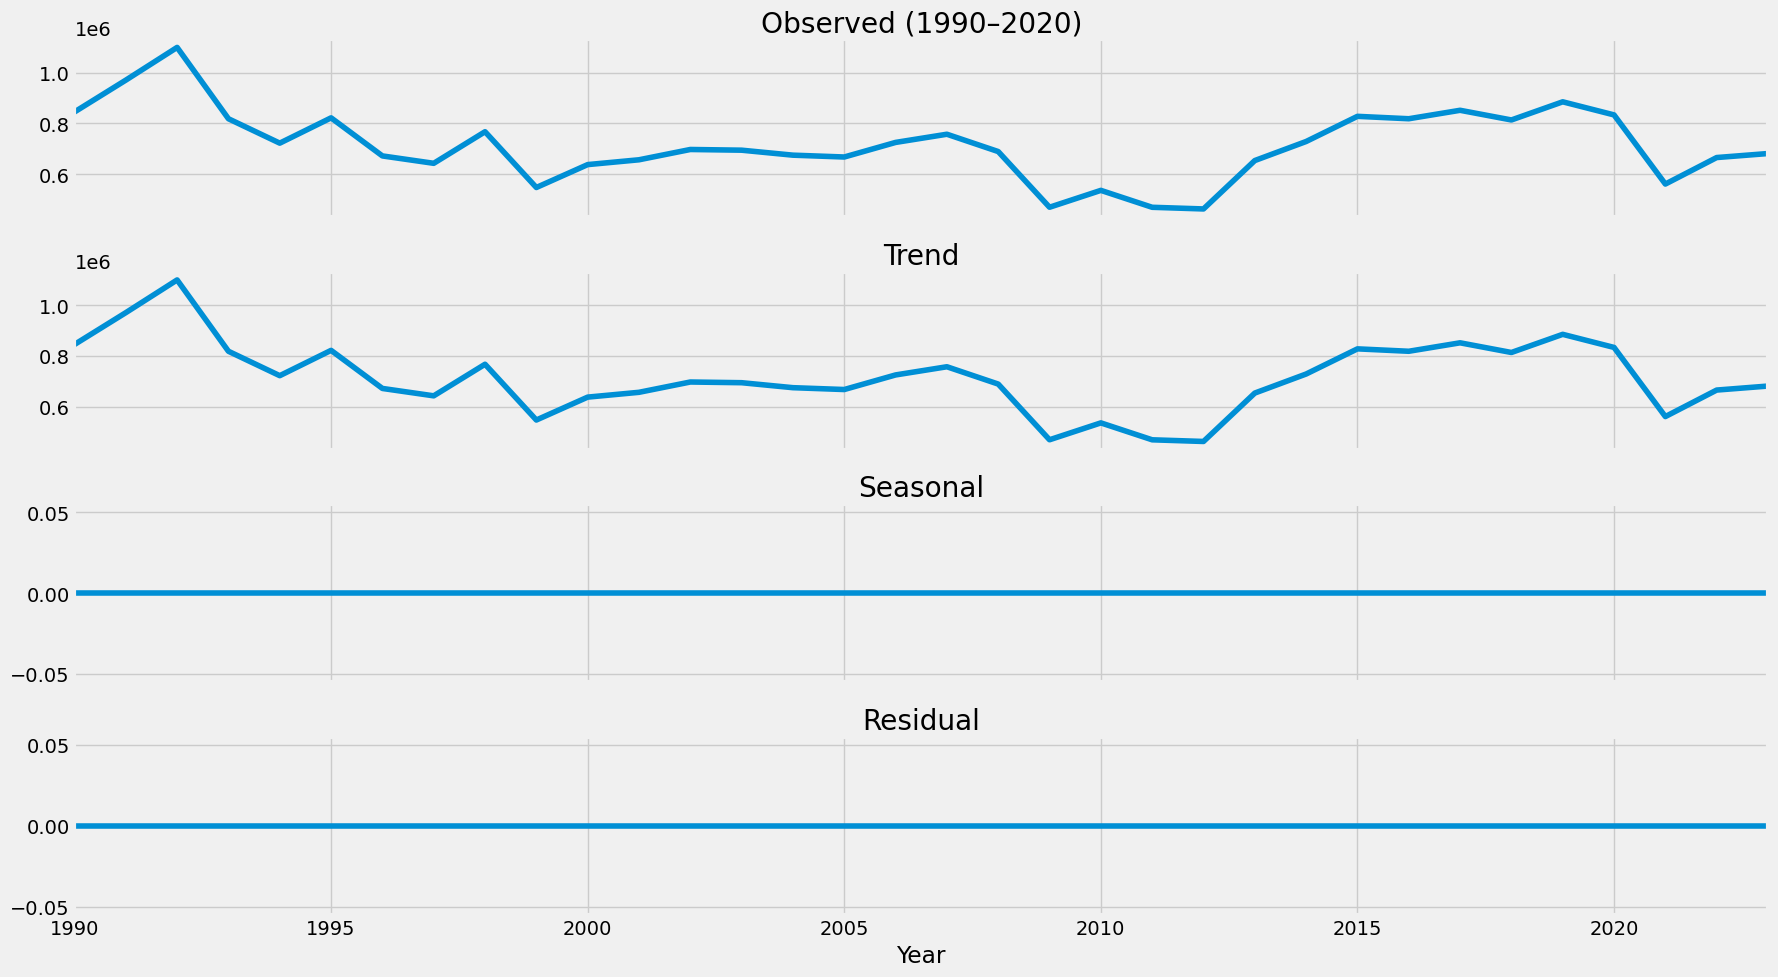

In [41]:
# Plot each component manually with clear titles and shared x-axis
fig, axes = plt.subplots(4, 1, figsize=(18, 10), sharex=True)

df_recent['production_tonnes'].plot(ax=axes[0])
axes[0].set_title('Observed (1990–2020)')

decomposition.trend.plot(ax=axes[1])
axes[1].set_title('Trend')

decomposition.seasonal.plot(ax=axes[2])
axes[2].set_title('Seasonal')

decomposition.resid.plot(ax=axes[3])
axes[3].set_title('Residual')

axes[3].set_xlabel('Year')
plt.tight_layout()
plt.show()

##### Time-Series Decomposition Analysis (1990–2020)
- Chart 1 – Observed: Coffee production in Colombia fluctuates between roughly 800,000 and 1,000,000 tonnes. There’s visible variation, but no repeating seasonal cycles.
- Chart 2 – Trend: Production declined from 1990 to around 2010, then rose until about 2018, followed by a slight drop. This shows long-term shifts in output.
- Chart 3 – Seasonal: No seasonal pattern was found — the seasonal line is flat at 0.
- Chart 4 – Residual: The leftover noise is minimal and flat, meaning the model captured most of the variation in the observed data


## 06. Testing for stationarity

In [42]:
# Import the Augmented Dickey-Fuller test from statsmodels.tsa.stattools
from statsmodels.tsa.stattools import adfuller

# Define a reusable function to run the Dickey-Fuller test and format the output
def dickey_fuller(timeseries):
    # Run the test with autolag set to 'AIC' for optimal lag selection
    test = adfuller(timeseries, autolag='AIC')
    
    # Format the results into a labeled pandas Series
    result = pd.Series(test[0:4], index=[
        'Test Statistic',
        'p-value',
        'Number of Lags Used',
        'Number of Observations Used'
    ])
    
    # Append critical values to the result
    for key, value in test[4].items():
        result[f'Critical Value ({key})'] = value
    
    # Print the full result
    print('Dickey-Fuller Stationarity Test:')
    print(result)

# Apply the test to Colombia's coffee production series
dickey_fuller(df_colombia['production_tonnes'])

Dickey-Fuller Stationarity Test:
Test Statistic                 -2.865658
p-value                         0.049490
Number of Lags Used             0.000000
Number of Observations Used    62.000000
Critical Value (1%)            -3.540523
Critical Value (5%)            -2.909427
Critical Value (10%)           -2.592314
dtype: float64


##### Test Results (1990–2020)
- Test Statistic: –2.87
- p-value: 0.049
- Critical Value (5%): –2.91
##### Interpretation
The p-value is just below 0.05, which allows us to reject the null hypothesis and conclude that the series is likely stationary.

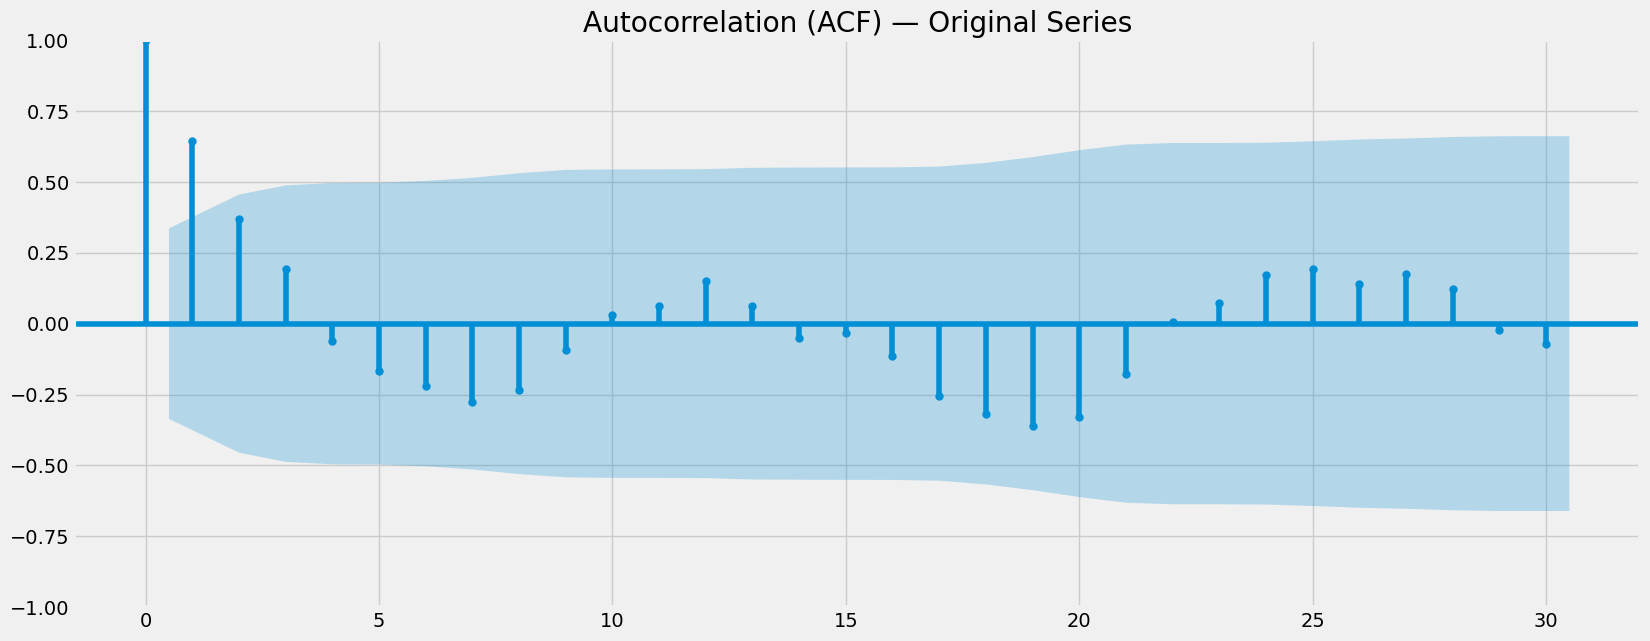

In [46]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot autocorrelation for the original production series (1990–2020)
plot_acf(df_recent['production_tonnes'], lags=30)
plt.title('Autocorrelation (ACF) — Original Series')
plt.show()

## 07. Summary of Stationarity and Autocorrelation Analysis

I conducted a Dickey-Fuller test on Colombia’s coffee production data (1990–2020) and found a p-value of 0.049, allowing me to reject the null hypothesis and conclude that the series is likely stationary. As a result, I did not apply differencing. I then plotted the Autocorrelation Function (ACF), which showed strong autocorrelation at lag 1 and moderate correlation at lags 2–4, with no significant seasonal patterns. This suggests the series has short-term dependencies and is suitable for low-order ARIMA modeling without further transformation.